# 10 — Transport models at every scale

How does each modeling stage behave as networks grow? This notebook walks the
scale ladder — from the 76-link Sioux Falls toy, through the bundled island and
regional models, to synthetic grids of up to 50,000 links generated on the fly —
and times every stage at every size. All data is embedded or generated
in-notebook; nothing is downloaded.

In [1]:
import time
import warnings
from pathlib import Path
from tempfile import gettempdir
from uuid import uuid4

import numpy as np
import pandas as pd

from aequilibrae.project import Project
from aequilibrae.utils.create_example import create_example
from aequilibrae.paths import TrafficAssignment, TrafficClass, NetworkSkimming
from aequilibrae.matrix import AequilibraeMatrix

warnings.filterwarnings("ignore")

rows = []
for name in ["sioux_falls", "nauru", "coquimbo"]:
    p = create_example(str(Path(gettempdir()) / uuid4().hex), name)
    with p.db_connection as conn:
        links, nodes = conn.execute(
            "select (select count(*) from links), (select count(*) from nodes)").fetchone()
        try:
            zones = conn.execute("select count(*) from zones").fetchone()[0]
        except Exception:
            zones = None
    rows.append({"model": name, "links": links, "nodes": nodes, "zones": zones})
    p.close()

pd.DataFrame(rows)

,model,links,nodes,zones
0,sioux_falls,76,24,24
1,nauru,1389,1239,0
2,coquimbo,19983,15724,133


## A synthetic network generator

Grid networks of any size, built through the standard editing API — every link
insert passes through the database consistency triggers that create nodes and
maintain `a_node`/`b_node`/`distance`, exactly as interactive editing does.

In [2]:
def build_grid_model(folder, n_links, n_centroids=25):
    """A square-grid model with n_links links and evenly spread centroids."""
    project = Project()
    project.new(folder)
    side = int(np.ceil((1 + np.sqrt(1 + 2 * n_links)) / 2))  # 2*s*(s-1) edges >= n_links
    lon0, lat0, step = 151.0, -33.0, 0.001

    with project.db_connection as conn:
        lt = conn.execute("select link_type from link_types limit 1").fetchone()[0]
        lid = 0
        for i in range(side):
            for j in range(side):
                x, y = lon0 + j * step, lat0 + i * step
                for x2, y2 in ((x + step, y), (x, y + step)):
                    if x2 >= lon0 + side * step or y2 >= lat0 + side * step or lid >= n_links:
                        continue
                    lid += 1
                    conn.execute(
                        "INSERT INTO links (link_id, a_node, b_node, link_type, modes, direction, "
                        "geometry) VALUES (?, 0, 0, ?, 'c', 0, GeomFromText(?, 4326))",
                        (lid, lt, f"LINESTRING({x} {y}, {x2} {y2})"))
        # free-flow attributes for assignment
        conn.execute("update links set speed_ab = 50, speed_ba = 50, "
                     "capacity_ab = 1000, capacity_ba = 1000, "
                     "travel_time_ab = distance / 1000.0 / 50 * 60, "
                     "travel_time_ba = distance / 1000.0 / 50 * 60")
        # evenly spread centroids
        node_ids = [r[0] for r in conn.execute("select node_id from nodes order by node_id")]
        stride = max(1, len(node_ids) // n_centroids)
        picks = node_ids[stride // 2::stride][:n_centroids]
        conn.executemany("update nodes set is_centroid = 1 where node_id = ?",
                         [(n,) for n in picks])
        conn.commit()
    return project

## Timing every stage at every scale

For each network size: build the network link-by-link, build the graph, skim all
centroid pairs, and run 10 iterations of BPR equilibrium assignment on a uniform
demand matrix.

In [3]:
def run_at_scale(n_links):
    folder = str(Path(gettempdir()) / uuid4().hex)
    t0 = time.perf_counter(); project = build_grid_model(folder, n_links)
    t_build = time.perf_counter() - t0

    t0 = time.perf_counter()
    project.network.build_graphs(modes=["c"])
    graph = project.network.graphs["c"]
    graph.set_graph("travel_time")
    graph.set_skimming(["travel_time"])
    graph.set_blocked_centroid_flows(False)
    t_graph = time.perf_counter() - t0

    t0 = time.perf_counter()
    NetworkSkimming(graph).execute()
    t_skim = time.perf_counter() - t0

    demand = AequilibraeMatrix()
    demand.create_empty(zones=graph.num_zones, matrix_names=["demand"], memory_only=True)
    demand.index = graph.centroids[:]
    demand.matrices[:, :, 0] = 5.0
    demand.computational_view()

    t0 = time.perf_counter()
    assig = TrafficAssignment()
    assig.add_class(TrafficClass(name="car", graph=graph, matrix=demand))
    assig.set_vdf("BPR"); assig.set_vdf_parameters({"alpha": 0.15, "beta": 4.0})
    assig.set_capacity_field("capacity"); assig.set_time_field("travel_time")
    assig.set_algorithm("msa"); assig.max_iter = 10; assig.rgap_target = 1e-10
    assig.execute()
    t_assign = time.perf_counter() - t0

    res = assig.results()
    row = {"links": n_links, "network_build_s": round(t_build, 2),
           "graph_s": round(t_graph, 2), "skim_s": round(t_skim, 2),
           "assignment_10it_s": round(t_assign, 2)}
    print(row, flush=True)
    return row, project, res


timings = []
for n in [1_000, 5_000, 20_000, 50_000]:
    row, project, res = run_at_scale(n)
    timings.append(row)
    if n < 50_000:
        project.close()

scaling = pd.DataFrame(timings).set_index("links")
scaling

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

{'links': 1000, 'network_build_s': 1.12, 'graph_s': 0.06, 'skim_s': 0.06, 'assignment_10it_s': 0.4}


[interactive offline map - run the notebook to display]

...

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

[interactive offline map - run the notebook to display]

{'links': 50000, 'network_build_s': 41.79, 'graph_s': 0.97, 'skim_s': 0.06, 'assignment_10it_s': 0.38}


,network_build_s,graph_s,skim_s,assignment_10it_s
links,,,,
1000,1.12,0.06,0.06,0.40
5000,4.16,0.21,0.12,0.31
20000,18.45,0.51,0.08,0.43
50000,41.79,0.97,0.06,0.38


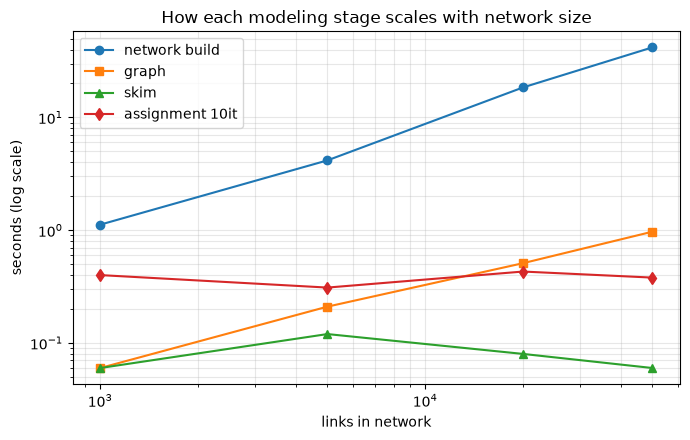

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
for col, marker in [("network_build_s", "o"), ("graph_s", "s"),
                    ("skim_s", "^"), ("assignment_10it_s", "d")]:
    ax.loglog(scaling.index, scaling[col].clip(lower=1e-3), marker=marker,
              label=col.replace("_s", "").replace("_", " "))
ax.set_xlabel("links in network")
ax.set_ylabel("seconds (log scale)")
ax.set_title("How each modeling stage scales with network size")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()

Every stage scales near-linearly with link count — including trigger-maintained
network building, whose per-link cost is flat from the first thousand links to the
fiftieth. On this ladder, a laptop covers everything from sketch models to a
metropolitan-scale network without leaving the notebook.

## Seeing a large model's results

The 50,000-link grid with its assigned flows, live on a offline map.

In [5]:
# Maps, cartographic standards and UK geography helpers.
# Model logic stays in the notebook; everything reusable lives in notebooks/uktools/.
from uktools import *


In [6]:
# field()/constant() symbology builders come from the map helper cell

flow_col = [c for c in res.columns if c.endswith("_tot")][0]
links_gdf = project.network.links.data
loaded = links_gdf.merge(res.reset_index(), on="link_id")
loaded = loaded[loaded[flow_col] > 0]

doc = new_map(links_gdf, zoom=13)
add_gdf(doc, loaded[["link_id", flow_col, "geometry"]], "assigned flows",
        symbology=[[field(flow_col).colormap("YlOrRd", domain=(0.0, float(loaded[flow_col].max()))).encoding("stroke"),
                field(flow_col).scalar(domain=(0.0, float(loaded[flow_col].max())),
                                       output_range=(0.8, 6.5)).encoding("stroke-width")]])
doc

[interactive offline map - run the notebook to display]

## Picking the right scale

| Scale | Links | Typical use | Feel |
|---|---|---|---|
| Toy (Sioux Falls) | ~10² | algorithm teaching, unit tests | instant |
| Small town / island (Nauru) | ~10²–10³ | sketch planning | instant |
| Regional city (Coquimbo) | ~10⁴ | full 4-step models (notebook 09) | seconds per stage |
| Metropolitan (synthetic 50k) | ~10⁴–10⁵ | corridor & network studies | seconds–minutes per stage |

Beyond this, the same workflow applies — assignment iterations dominate, so
converged equilibria on national-scale networks simply become batch jobs rather
than interactive sessions.